In [1]:
import h5py
import numpy as np
import os

In [57]:
data_folder_prefix = "/vision/u"
image_folder = "/vision/u/chengshu/figure_images"

task = "dishes_away"
if task == "pick_cup":
    paths = [
        [f"{data_folder_prefix}/chengshu/momagen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D0/demo.hdf5" for i in range(2)],
        [f"{data_folder_prefix}/chengshu/momagen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D1/demo.hdf5" for i in range(1)],
        [f"{data_folder_prefix}/chengshu/mimicgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_mimicgen_task_D0/demo.hdf5" for i in range(1)],
        [f"{data_folder_prefix}/chengshu/skillgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_skillgen_task_D0/demo.hdf5" for i in range(1)],
    ]
elif task == "tidy_table":
    paths = [
        [f"{data_folder_prefix}/chengshu/momagen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D0/demo.hdf5" for i in range(2)],
        [f"{data_folder_prefix}/chengshu/momagen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D1/demo.hdf5" for i in range(1)],
        [f"{data_folder_prefix}/chengshu/mimicgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_mimicgen_task_D0/demo.hdf5" for i in range(1)],
        [f"{data_folder_prefix}/chengshu/skillgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_skillgen_task_D0/demo.hdf5" for i in range(1)],
    ]
elif task == "dishes_away":
    paths = [
        [f"{data_folder_prefix}/chengshu/momagen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D0/demo.hdf5" for i in range(1)],
        [f"{data_folder_prefix}/mengdixu/momagen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D1/demo.hdf5" for i in range(25)],
        [f"{data_folder_prefix}/chengshu/mimicgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_mimicgen_task_D0/demo.hdf5" for i in range(25)],
        [f"{data_folder_prefix}/chengshu/skillgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_skillgen_task_D0/demo.hdf5" for i in range(25)],
    ]
elif task == "clean_pan":
    paths = [
        [f"{data_folder_prefix}/chengshu/momagen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D0/demo.hdf5" for i in range(1)],
        [f"{data_folder_prefix}/chengshu/momagen/{task}_full_vis/r1_{task}_worker_{i}/demo_src_r1_{task}_task_D1/demo.hdf5" for i in range(25)],
        [f"{data_folder_prefix}/chengshu/mimicgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_mimicgen_task_D0/demo.hdf5" for i in range(25)],
        [f"{data_folder_prefix}/chengshu/skillgen/{task}_full/r1_{task}_worker_{i}/demo_src_r1_{task}_skillgen_task_D0/demo.hdf5" for i in range(25)],
    ]

In [45]:
left_arm_joints = np.array([10, 12, 14, 16, 18, 20])
right_arm_joints = np.array([11, 13, 15, 17, 19, 21])
base_joints = np.array([0, 1, 5])
torso_joints = np.array([6, 7, 8,9])
left_arm_plus_torso = np.concatenate((torso_joints, left_arm_joints))

In [48]:
# For all joints
d0_data = []
num_demos_collected = 0
for path in paths[0]:
    print(path)
    with h5py.File(path, "r") as f:
        print(len(f["data"]))
        for demo_key in f["data"]:
            if num_demos_collected == 50:
                break
            num_demos_collected += 1
            d0_data.append(f["data"][demo_key]["obs"]["joint_qpos"][:, left_arm_plus_torso])
assert num_demos_collected == 50, num_demos_collected
d0_data = np.concatenate(d0_data, axis=0)
print(d0_data.shape)

/mnt/chengshu/momagen/dishes_away_full/r1_dishes_away_worker_0/demo_src_r1_dishes_away_task_D0/demo.hdf5
50
(175806, 10)


In [58]:
# For all joints
d1_data = []
num_demos_collected = 0
for path in paths[1]:
    print(path)
    with h5py.File(path, "r") as f:
        print(len(f["data"]))
        for demo_key in f["data"]:
            if num_demos_collected == 50:
                break
            num_demos_collected += 1
            d1_data.append(f["data"][demo_key]["obs"]["joint_qpos"][:, left_arm_plus_torso])
assert num_demos_collected == 50, num_demos_collected
d1_data = np.concatenate(d1_data, axis=0)
print(d1_data.shape)

/mnt/chengshu/momagen/dishes_away_full_vis/r1_dishes_away_worker_0/demo_src_r1_dishes_away_task_D1/demo.hdf5
2
/mnt/chengshu/momagen/dishes_away_full_vis/r1_dishes_away_worker_1/demo_src_r1_dishes_away_task_D1/demo.hdf5
2
/mnt/chengshu/momagen/dishes_away_full_vis/r1_dishes_away_worker_2/demo_src_r1_dishes_away_task_D1/demo.hdf5
2
/mnt/chengshu/momagen/dishes_away_full_vis/r1_dishes_away_worker_3/demo_src_r1_dishes_away_task_D1/demo.hdf5


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/chengshu/momagen/dishes_away_full_vis/r1_dishes_away_worker_3/demo_src_r1_dishes_away_task_D1/demo.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [36]:
mimicgen_data = []
num_demos_collected = 0
for path in paths[2]:
    print(path)
    with h5py.File(path, "r") as f:
        print(len(f["data"]))
        for demo_key in f["data"]:
            if num_demos_collected == 50:
                break
            num_demos_collected += 1
            mimicgen_data.append(f["data"][demo_key]["obs"]["joint_qpos"][:, left_arm_plus_torso])
assert num_demos_collected == 50, num_demos_collected
mimicgen_data = np.concatenate(mimicgen_data, axis=0)
print(mimicgen_data.shape)

/mnt/chengshu/mimicgen/pick_cup_full/r1_pick_cup_worker_0/demo_src_r1_pick_cup_mimicgen_task_D0/demo.hdf5
50
(46267, 10)


In [37]:
skillgen_data = []
num_demos_collected = 0
for path in paths[3]:
    print(path)
    with h5py.File(path, "r") as f:
        print(len(f["data"]))
        for demo_key in f["data"]:
            if num_demos_collected == 50:
                break
            num_demos_collected += 1
            skillgen_data.append(f["data"][demo_key]["obs"]["joint_qpos"][:, left_arm_plus_torso])
assert num_demos_collected == 50, num_demos_collected
skillgen_data = np.concatenate(skillgen_data, axis=0)
print(skillgen_data.shape)

/mnt/chengshu/skillgen/pick_cup_full/r1_pick_cup_worker_0/demo_src_r1_pick_cup_skillgen_task_D0/demo.hdf5
50
(39060, 10)


In [18]:
# # For left arm only
# num_demos = len(f1["data"].keys())
# data1 = []
# for i in range(num_demos):
#     if i == 0:
#         data1 = f1["data"][f"demo_{i}"]["obs"]["joint_qpos"][:, left_arm_joints]
#     else:
#         data1 = np.concatenate((data1, f1["data"][f"demo_{i}"]["obs"]["joint_qpos"][:, left_arm_joints]), axis=0)

In [33]:
# from scipy.spatial.transform import Rotation as R

# def pose_to_vector(pose_array: np.ndarray) -> np.ndarray:
#     """
#     Converts a batch of homogeneous transformation matrices (N, 4, 4)
#     into (N, 6) vectors: [x, y, z, rx, ry, rz] where r is the rotation vector.
#     """
#     assert pose_array.ndim == 3 and pose_array.shape[1:] == (4, 4), \
#         "Input must be of shape (N, 4, 4)"
    
#     # Extract translation: shape (N, 3)
#     translations = pose_array[:, :3, 3]
    
#     # Extract rotations: shape (N, 3, 3)
#     rotations = pose_array[:, :3, :3]
    
#     # Convert rotation matrices to rotation vectors: shape (N, 3)
#     rvecs = R.from_matrix(rotations).as_rotvec()
    
#     # Concatenate translations and rotation vectors: shape (N, 6)
#     return np.hstack((translations, rvecs))


# # EEF poses
# side = "left"
# num_demos = len(f1["data"].keys())
# data1 = []
# for i in range(num_demos):
#     if side =="left":
#         res = np.array(f1["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, :4]
#     elif side == "right":
#         res = np.array(f1["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, 4:]
    
#     res = pose_to_vector(res)
#     if i == 0:
#         data1 = res
#     else:
#         data1 = np.concatenate((data1, res), axis=0)

# num_demos = len(f2["data"].keys())
# data2 = []
# for i in range(num_demos):
#     if side =="left":
#         res = np.array(f2["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, :4]
#     elif side == "right":
#         res = np.array(f2["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, 4:]
    
#     res = pose_to_vector(res)
#     if i == 0:
#         data2 = res
#     else:
#         data2 = np.concatenate((data2, res), axis=0)

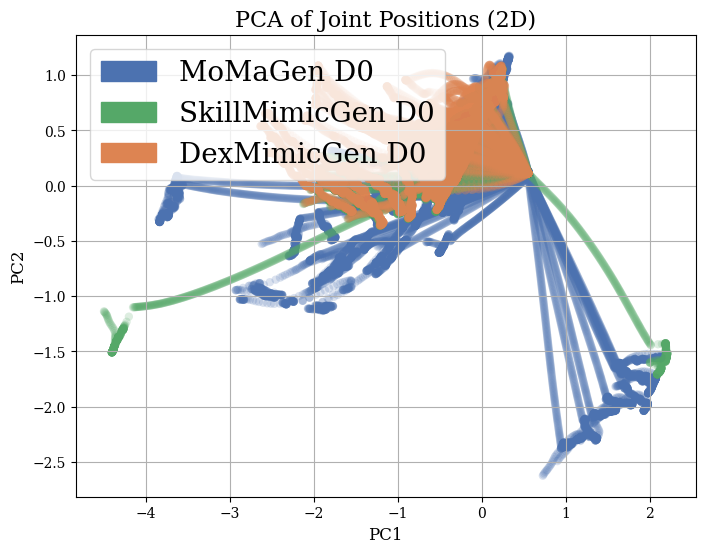

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import seaborn as sns

np.random.seed(0)
dataset1 = d0_data
dataset2 = d1_data
dataset3 = mimicgen_data
dataset4 = skillgen_data

# Combine the datasets
combined_data = np.vstack([dataset1, dataset2, dataset3, dataset4])

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_data)

# Lengths of original datasets
len1 = len(dataset1)
len2 = len(dataset2)
len3 = len(dataset3)
len4 = len(dataset4)

# Cumulative indices
end1 = len1
end2 = end1 + len2
end3 = end2 + len3
end4 = end3 + len4  # or just len(pca_result)

# Split PCA result
pca_dataset1 = pca_result[:end1]
pca_dataset2 = pca_result[end1:end2]
pca_dataset3 = pca_result[end2:end3]
pca_dataset4 = pca_result[end3:end4]

# Plot
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

plt.figure(figsize=(8, 6))
palette = sns.color_palette("deep")

alpha = 0.2
sns.scatterplot(x=pca_dataset1[:, 0], y=pca_dataset1[:, 1], label='MoMaGen D0', alpha=alpha, color=palette[0], edgecolor="none")
sns.scatterplot(x=pca_dataset4[:, 0], y=pca_dataset4[:, 1], label='SkillMimicGen D0', alpha=alpha, color=palette[2], edgecolor="none")
sns.scatterplot(x=pca_dataset3[:, 0], y=pca_dataset3[:, 1], label='DexMimicGen D0', alpha=alpha, color=palette[1], edgecolor="none")


import matplotlib.patches as mpatches

# Create opaque legend handles manually
colors = [palette[0], palette[2], palette[1]]
labels = ['MoMaGen D0', 'SkillMimicGen D0', 'DexMimicGen D0']
handles = [mpatches.Patch(color=color, label=label) for color, label in zip(colors, labels)]

# Add legend with opaque markers
plt.legend(handles=handles, fontsize=20, loc='upper left')

plt.title('PCA of Joint Positions (2D)', fontsize=16)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
# plt.legend()
plt.grid(True)
# plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(image_folder, f"diversity_{task}_pca.png"))

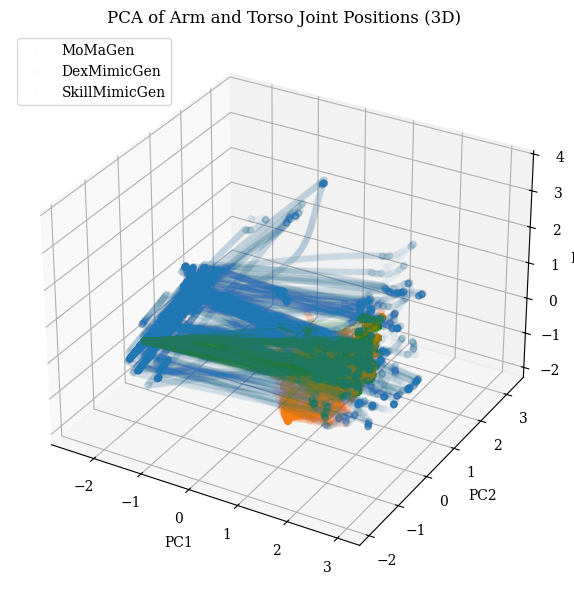

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


np.random.seed(0)
dataset1 = d0_data
dataset2 = d1_data
dataset3 = mimicgen_data
dataset4 = skillgen_data

# Combine the datasets
combined_data = np.vstack([dataset1, dataset2, dataset3, dataset4])

# Run PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(combined_data)

# Lengths of original datasets
len1 = len(dataset1)
len2 = len(dataset2)
len3 = len(dataset3)
len4 = len(dataset4)

# Cumulative indices
end1 = len1
end2 = end1 + len2
end3 = end2 + len3
end4 = end3 + len4  # or just len(pca_result)

# Split PCA result
pca_dataset1 = pca_result[:end1]
pca_dataset2 = pca_result[end1:end2]
pca_dataset3 = pca_result[end2:end3]
pca_dataset4 = pca_result[end3:end4]

# Plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

ax.scatter(pca_dataset1[:, 0], pca_dataset1[:, 1], pca_dataset1[:, 2], label='MoMaGen', alpha=0.01)
# ax.scatter(pca_dataset2[:, 0], pca_dataset2[:, 1], pca_dataset2[:, 2], label='D1', alpha=0.01)
ax.scatter(pca_dataset3[:, 0], pca_dataset3[:, 1], pca_dataset3[:, 2], label='DexMimicGen', alpha=0.01)
ax.scatter(pca_dataset4[:, 0], pca_dataset4[:, 1], pca_dataset4[:, 2], label='SkillMimicGen', alpha=0.01)


plt.title('PCA of Arm and Torso Joint Positions (3D)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [113]:
2 + 489 * 1


491

In [114]:
2 + 489 * 2

980

In [87]:
for color in palette:
    print(np.array(color) * 255)

[ 76. 114. 176.]
[221. 132.  82.]
[ 85. 168. 104.]
[196.  78.  82.]
[129. 114. 179.]
[147. 120.  96.]
[218. 139. 195.]
[140. 140. 140.]
[204. 185. 116.]
[100. 181. 205.]


In [94]:
palette

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]